In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam

torch.manual_seed(42)
np.random.seed(42)

# ── Robot parameters (same as FF-NN lecture) ──────────────
L1, L2 = 1.0, 1.0    # link lengths (m)
m1, m2 = 1.0, 1.0    # link masses (kg)
g_acc  = 9.81

def inverse_dynamics(q1, q2, dq1, dq2, ddq1, ddq2):
    """Analytical inverse dynamics — same function as FF-NN lecture."""
    M11 = (m1+m2)*L1**2 + m2*L2**2 + 2*m2*L1*L2*np.cos(q2)
    M12 = m2*L2**2 + m2*L1*L2*np.cos(q2)
    M22 = m2*L2**2
    h   = m2*L1*L2*np.sin(q2)
    C1  = -h*dq2**2 - 2*h*dq1*dq2
    C2  =  h*dq1**2
    g1  = (m1+m2)*g_acc*L1*np.cos(q1) + m2*g_acc*L2*np.cos(q1+q2)
    g2  =  m2*g_acc*L2*np.cos(q1+q2)
    return (M11*ddq1 + M12*ddq2 + C1 + g1,
            M12*ddq1 + M22*ddq2 + C2 + g2)

In [ ]:
N = 5000
q1   = np.random.uniform(-np.pi,   np.pi,   N)
q2   = np.random.uniform(-np.pi,   np.pi,   N)
dq1  = np.random.uniform(-2*np.pi, 2*np.pi, N)
dq2  = np.random.uniform(-2*np.pi, 2*np.pi, N)
ddq1 = np.random.uniform(-10,      10,      N)
ddq2 = np.random.uniform(-10,      10,      N)

tau1, tau2 = inverse_dynamics(q1, q2, dq1, dq2, ddq1, ddq2)

# Convert to PyTorch tensors
Q   = torch.tensor(np.column_stack([q1,   q2]),   dtype=torch.float32)
DQ  = torch.tensor(np.column_stack([dq1,  dq2]),  dtype=torch.float32)
DDQ = torch.tensor(np.column_stack([ddq1, ddq2]), dtype=torch.float32)
TAU = torch.tensor(np.column_stack([tau1, tau2]), dtype=torch.float32)

# Train / test split (90 / 10)
n_tr = int(0.9 * N)
Q_tr,   Q_te   = Q[:n_tr],   Q[n_tr:]
DQ_tr,  DQ_te  = DQ[:n_tr],  DQ[n_tr:]
DDQ_tr, DDQ_te = DDQ[:n_tr], DDQ[n_tr:]
TAU_tr, TAU_te = TAU[:n_tr], TAU[n_tr:]

print(f"Training: {n_tr} samples | Test: {N - n_tr} samples")
print(f"Sub-network input shape: {Q_tr.shape}  ← only q, NOT (q, dq, ddq)")
print(f"Full state shape:        {torch.cat([Q_tr, DQ_tr, DDQ_tr], dim=1).shape}")

Training: 4500 samples | Test: 500 samples
Sub-network input shape: torch.Size([4500, 2])  ← only q, NOT (q, dq, ddq)
Full state shape:        torch.Size([4500, 6])


In [ ]:
class DeLaN2R(nn.Module):

    def __init__(self, hidden_size=64, n_layers=2):
        super(DeLaN2R, self).__init__()

        def mlp(out_dim):
            """Small MLP: always takes q (2-dim) as input."""
            layers = [nn.Linear(2, hidden_size), nn.Softplus()]
            for _ in range(n_layers - 1):
                layers += [nn.Linear(hidden_size, hidden_size), nn.Softplus()]
            layers.append(nn.Linear(hidden_size, out_dim))
            return nn.Sequential(*layers)

        # Head 1: diagonal of L — Softplus in forward() forces l > 0
        self.l_diag_net = mlp(2)   # outputs [l11, l22]

        # Head 2: off-diagonal of L — linear, no constraint
        self.l_off_net  = mlp(1)   # outputs [l21]

        # Head 3: potential energy — scalar, Softplus activations for smoothness
        self.v_net      = mlp(1)   # outputs V(q) ∈ ℝ

    # ----------------------------------------------------------
    def get_H(self, q):
        """
        Compute SPD mass matrix H(q) = L(q) · L(q)ᵀ

        2-DOF structure:
            L = [ l11   0  ]     H = [ l11²         l11·l21    ]
                [ l21  l22 ]         [ l11·l21    l21² + l22²  ]
        """
        batch = q.shape[0]

        # Softplus + ε makes diagonal strictly positive
        ld = torch.nn.functional.softplus(self.l_diag_net(q)) + 1e-6  # (batch, 2)
        lo = self.l_off_net(q)                                          # (batch, 1)

        L = torch.zeros(batch, 2, 2, dtype=q.dtype, device=q.device)
        L[:, 0, 0] = ld[:, 0]   # l11
        L[:, 1, 1] = ld[:, 1]   # l22
        L[:, 1, 0] = lo[:, 0]   # l21

        return torch.bmm(L, L.transpose(1, 2))   # H = L·Lᵀ, always SPD

    # ----------------------------------------------------------
    def forward(self, q, dq, ddq):
        """
        Euler-Lagrange inverse dynamics:
            τ = H(q)·ddq  +  [Ḣ(q)·dq − (∂T/∂q (1/2))^T]  +  g(q)
                ─────────        ─────────────────     ─────
                inertial              Coriolis          gravity
        """
        # Need autograd w.r.t. q to compute g = ∂V/∂q and ∂T/∂q
        q = q.detach().requires_grad_(True)

        # ── GRAVITY: g(q) = ∂V/∂q ──────────────────────────
        V = self.v_net(q).squeeze(-1)                          # (batch,)
        g = torch.autograd.grad(
            V.sum(), q,
            create_graph=True, retain_graph=True
        )[0]                                                   # (batch, 2)

        # ── MASS MATRIX: H(q) = L·Lᵀ ───────────────────────
        H = self.get_H(q)                                      # (batch, 2, 2)

        # ── KINETIC ENERGY: T = 0.5 · dqᵀ H(q) dq ─────────
        T = 0.5 * torch.einsum('bi,bij,bj->b', dq, H, dq)    # (batch,)

        # ── ∂T/∂q via autograd ─────────────────────────────
        dT_dq = torch.autograd.grad(
            T.sum(), q,
            create_graph=True, retain_graph=True
        )[0]                                                   # (batch, 2)

        # ── Ḣ·dq: time derivative of H multiplied by dq ────
        # [Ḣ·dq]_i = Σ_j  (∂H_ij/∂q · dq) · dq_j
        # Accumulate without in-place ops (safer for autograd)
        rows = []
        for i in range(2):
            row_i = torch.zeros(q.shape[0], dtype=q.dtype, device=q.device)
            for j in range(2):
                dHij_dq = torch.autograd.grad(
                    H[:, i, j].sum(), q,
                    create_graph=True, retain_graph=True
                )[0]                                           # (batch, 2)
                dHij_dt = (dHij_dq * dq).sum(dim=1)          # chain rule: Σ_k ∂H/∂q_k · dq_k
                row_i   = row_i + dHij_dt * dq[:, j]         # accumulate Ḣ_ij · dq_j
            rows.append(row_i)
        Hdot_dq = torch.stack(rows, dim=1)                    # (batch, 2)

        # ── INERTIAL TERM: H(q)·ddq ────────────────────────
        H_ddq = torch.bmm(H, ddq.unsqueeze(-1)).squeeze(-1)  # (batch, 2)

        # ── ASSEMBLE: τ = H·ddq + Ḣ·dq − ∂T/∂q + g ───────
        return H_ddq + Hdot_dq - dT_dq + g

Training DeLaN...

Epoch   50/500  |  Loss: 8.53272
Epoch  100/500  |  Loss: 3.98303
Epoch  150/500  |  Loss: 1.26805
Epoch  200/500  |  Loss: 0.53951
Epoch  250/500  |  Loss: 0.27785
Epoch  300/500  |  Loss: 0.15534
Epoch  350/500  |  Loss: 0.10341
Epoch  400/500  |  Loss: 0.06394
Epoch  450/500  |  Loss: 0.03507
Epoch  500/500  |  Loss: 0.06066


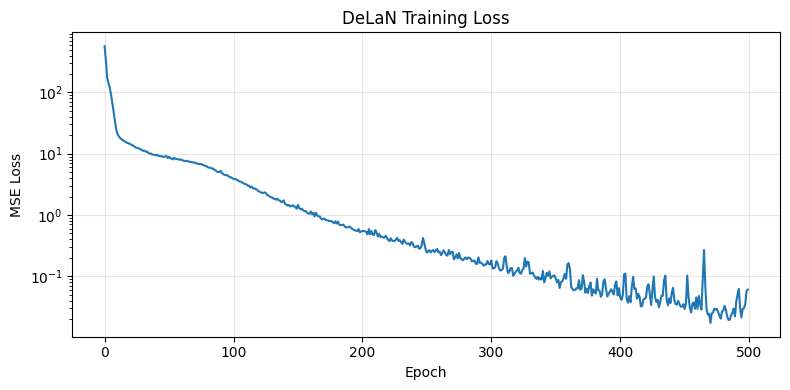

In [ ]:
model = DeLaN2R(hidden_size=64, n_layers=2)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

EPOCHS     = 500
BATCH_SIZE = 128
n_batches  = max(1, n_tr // BATCH_SIZE)
losses     = []

print("Training DeLaN...\n")
for epoch in range(EPOCHS):
    model.train()
    idx = torch.randperm(n_tr)
    epoch_loss = 0.0

    for b in range(n_batches):
        batch_idx = idx[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]

        tau_pred = model(Q_tr[batch_idx], DQ_tr[batch_idx], DDQ_tr[batch_idx])
        loss     = loss_fn(tau_pred, TAU_tr[batch_idx])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss / n_batches)
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d}/{EPOCHS}  |  Loss: {losses[-1]:.5f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.yscale("log")
plt.title("DeLaN Training Loss"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Test RMSE  τ₁: 0.2826 Nm
Test RMSE  τ₂: 0.1895 Nm


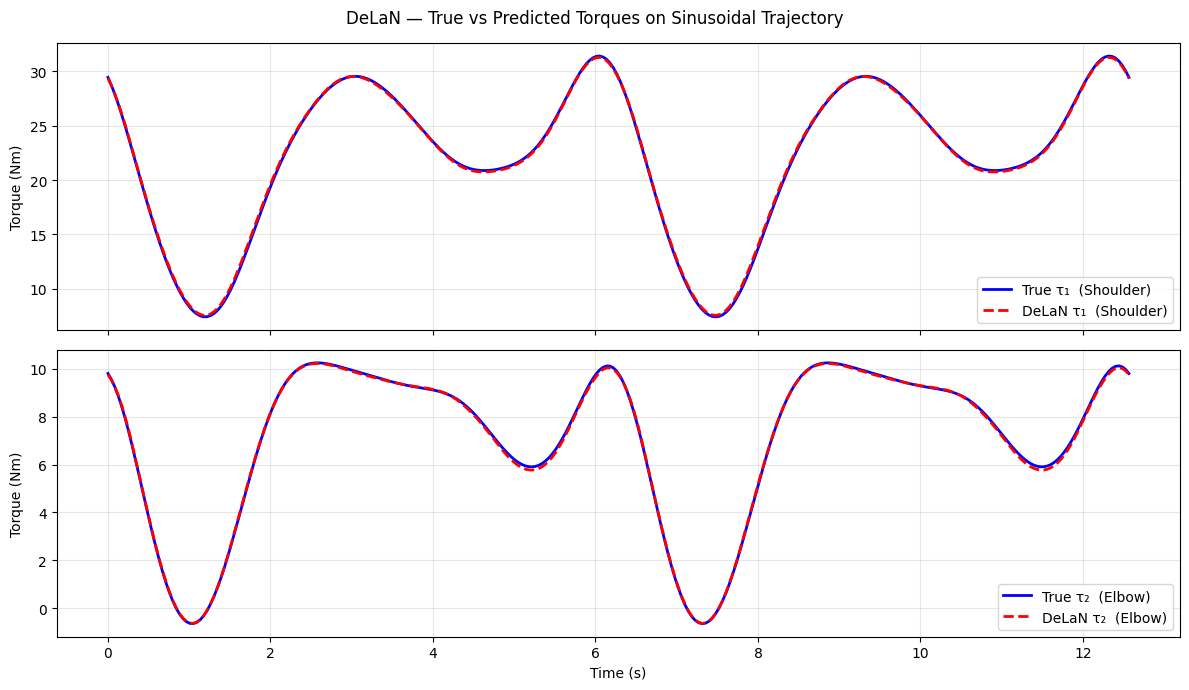

In [ ]:
def predict(q, dq, ddq):
    """
    DeLaN uses autograd internally, so torch.enable_grad() is required
    even at inference time — unlike a standard NN.
    """
    model.eval()
    with torch.enable_grad():
        return model(q, dq, ddq).detach()

# ── RMSE on random test set ────────────────────────────────
tau_pred_te = predict(Q_te, DQ_te, DDQ_te)
rmse1 = torch.sqrt(torch.mean((tau_pred_te[:, 0] - TAU_te[:, 0])**2)).item()
rmse2 = torch.sqrt(torch.mean((tau_pred_te[:, 1] - TAU_te[:, 1])**2)).item()
print(f"Test RMSE  τ₁: {rmse1:.4f} Nm")
print(f"Test RMSE  τ₂: {rmse2:.4f} Nm")

# ── Sinusoidal trajectory test ─────────────────────────────
t      = np.linspace(0, 4 * np.pi, 300)
q1_t   =  np.sin(t);          q2_t   =  0.5 * np.sin(2 * t)
dq1_t  =  np.cos(t);          dq2_t  =  np.cos(2 * t)
ddq1_t = -np.sin(t);          ddq2_t = -2.0 * np.sin(2 * t)

tau1_true, tau2_true = inverse_dynamics(q1_t, q2_t, dq1_t, dq2_t, ddq1_t, ddq2_t)

Q_tr_  = torch.tensor(np.column_stack([q1_t, q2_t]),     dtype=torch.float32)
DQ_tr_ = torch.tensor(np.column_stack([dq1_t, dq2_t]),   dtype=torch.float32)
DDQ_tr_= torch.tensor(np.column_stack([ddq1_t, ddq2_t]), dtype=torch.float32)

pred = predict(Q_tr_, DQ_tr_, DDQ_tr_).numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
labels = ["τ₁  (Shoulder)", "τ₂  (Elbow)"]
truths = [tau1_true, tau2_true]
for ax, true, pr, lbl in zip(axes, truths, pred.T, labels):
    ax.plot(t, true, 'b-',  lw=2, label=f"True {lbl}")
    ax.plot(t, pr,   'r--', lw=2, label=f"DeLaN {lbl}")
    ax.set_ylabel("Torque (Nm)"); ax.legend(); ax.grid(alpha=0.3)
axes[1].set_xlabel("Time (s)")
plt.suptitle("DeLaN — True vs Predicted Torques on Sinusoidal Trajectory")
plt.tight_layout(); plt.show()

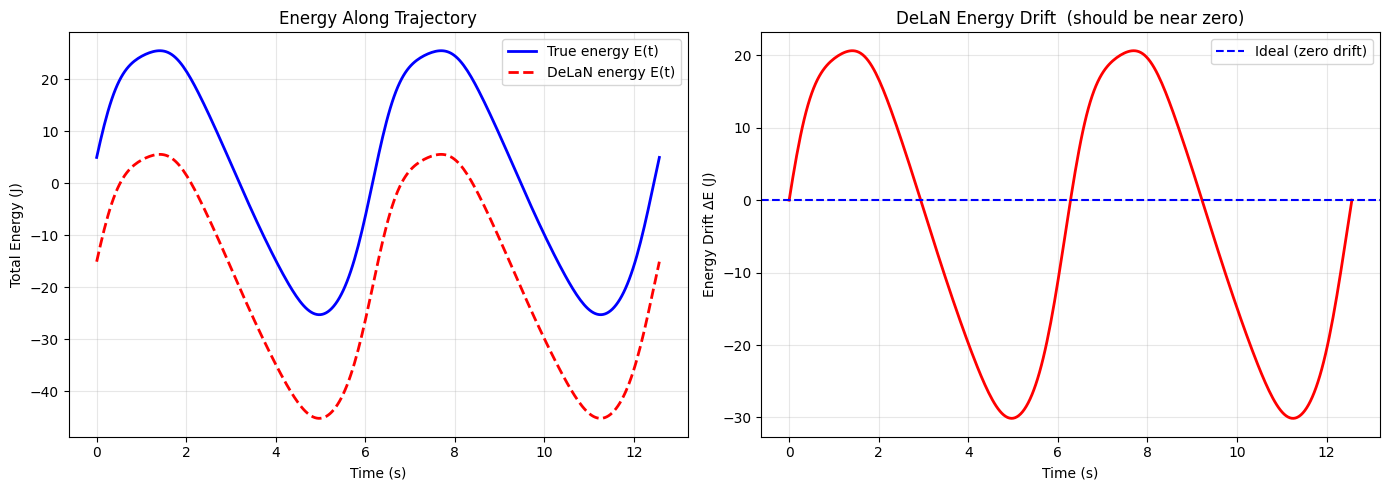


True energy range:        50.7556 J  (non-zero because trajectory is not free motion)
DeLaN max energy drift:   30.1210 J
DeLaN mean energy error:  19.9833 J


In [ ]:
# ══════════════════════════════════════════════════════════
#  ENERGY CONSERVATION TEST
#  Both models are simulated along the same sinusoidal
#  trajectory. Energy E = T + V is tracked at each step.
#  A correct physics model should show near-constant energy.
# ══════════════════════════════════════════════════════════

def true_energy(q1, q2, dq1, dq2):
    """Analytical mechanical energy: E = T + V"""
    M11 = (m1+m2)*L1**2 + m2*L2**2 + 2*m2*L1*L2*np.cos(q2)
    M12 = m2*L2**2 + m2*L1*L2*np.cos(q2)
    M22 = m2*L2**2
    T   = 0.5*(M11*dq1**2 + 2*M12*dq1*dq2 + M22*dq2**2)
    y1  = L1*np.sin(q1)
    y2  = L1*np.sin(q1) + L2*np.sin(q1+q2)
    V   = m1*g_acc*y1 + m2*g_acc*y2
    return float(T + V)

def delan_energy(q_np, dq_np):
    """DeLaN's mechanical energy from its learned H(q) and V(q)"""
    with torch.enable_grad():
        q_t  = torch.tensor(q_np,  dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        dq_t = torch.tensor(dq_np, dtype=torch.float32).unsqueeze(0)
        model.eval()
        H = model.get_H(q_t)
        T = 0.5 * torch.einsum('bi,bij,bj->b', dq_t, H, dq_t).item()
        V = model.v_net(q_t).item()
    return T + V

# Evaluate along the sinusoidal trajectory (no simulation needed —
# we just track what energy the model assigns to known states)
E_true   = []
E_delan  = []

for k in range(len(t)):
    E_true.append( true_energy(q1_t[k], q2_t[k], dq1_t[k], dq2_t[k]))
    E_delan.append(delan_energy(
        np.array([q1_t[k], q2_t[k]]),
        np.array([dq1_t[k], dq2_t[k]])
    ))

E_true  = np.array(E_true)
E_delan = np.array(E_delan)

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: energy over time
axes[0].plot(t, E_true,  'b-',  lw=2, label='True energy E(t)')
axes[0].plot(t, E_delan, 'r--', lw=2, label='DeLaN energy E(t)')
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Total Energy (J)")
axes[0].set_title("Energy Along Trajectory")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: residual drift
drift = E_delan - E_delan[0]
axes[1].plot(t, drift, 'r-', lw=2)
axes[1].axhline(0, color='blue', lw=1.5, linestyle='--', label='Ideal (zero drift)')
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Energy Drift ΔE (J)")
axes[1].set_title("DeLaN Energy Drift  (should be near zero)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nTrue energy range:        {E_true.max() - E_true.min():.4f} J  (non-zero because trajectory is not free motion)")
print(f"DeLaN max energy drift:   {np.abs(drift).max():.4f} J")
print(f"DeLaN mean energy error:  {np.mean(np.abs(E_delan - E_true)):.4f} J")